# 02 — Inferencia marginal 

En este tutorial entrenamos MAFs que modelan solo un subconjunto de parámetros,
marginalizando los demás. Esto permite inferir solo los parámetros de interés
mientras los nuisance se mantienen en sus bounds actuales.

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torch.distributions import Uniform
import zbi

%matplotlib inline

Cinco parámetros theta_0...theta_4 controlan la media de cinco Gaussianas independientes.
Cada gaussiana tiene 20 puntos, concatenados en un vector x de 100 dimensiones.

In [ ]:
class Gaussian5D(zbi.Simulator):
    def __init__(self):
        super().__init__()

    def simulate(self, theta: torch.Tensor, seed: int | None = None) -> torch.Tensor:
        if seed is not None:
            torch.manual_seed(seed)
        single = theta.ndim == 1
        if single:
            theta = theta.unsqueeze(0)
        x_parts = []
        for i in range(5):
            xi = torch.randn(theta.shape[0], 20) + theta[:, i:i+1]
            x_parts.append(xi)
        x = torch.cat(x_parts, dim=-1)  
        return x.squeeze(0) if single else x


class Embedding5D(nn.Module):
    def __init__(self, dim_in: int = 100, dim_out: int = 8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_in, 32),
            nn.ReLU(),
            nn.Linear(32, dim_out),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

Generamos el dato observado con θ_true = (-1, 2, 0, 1.5, -0.8) e inicializamos el experimento.

In [7]:
theta_true = (-1.0, 2.0, 0.0, 1.5, -0.8)
x_o = zbi.simulate_obs(Gaussian5D(), theta_true=theta_true, seed=42)

zbi.init(
    run_dir="runs/tutorial_02", x_o=x_o,
    simulator_class=Gaussian5D,
    embedding_class=Embedding5D,
    embedding_kwargs=dict(dim_in=100, dim_out=8),
    prior_low=(-3.0, -3.0, -3.0, -3.0, -3.0),
    prior_high=(3.0, 3.0, 3.0, 3.0, 3.0),
    dim_theta=5, dim_x=100,
    zarr_N=5000, zarr_chunk_size=128,
)
print("Experimento inicializado")

Experimento inicializado


### Ronda 0: entrenamiento full joint

Entrenamos un MAF sobre los 5 parámetros (sin interest_dims). Luego `update_proposal`
computa bounds truncados para todas las dimensiones.

In [8]:
zbi.simulate("runs/tutorial_02", round=0, n_sims=1000)
zbi.train("runs/tutorial_02", round=0, n_sims=1000)
zbi.update_proposal("runs/tutorial_02", checkpoint="round_00000_1000.pt", threshold=1e-6)
print("Ronda 0 completada")

Simulating: 100%|██████████| 1000/1000 [00:00<00:00, 2224.45it/s]


Ronda 0: 1000 sims nuevas, 1000 acumuladas (offset=0)
Usando simulaciones: offset=0, n_sims=1000
Epoch   0  train_loss=16.5659  val_loss=16.0668
Epoch   1  train_loss=15.6134  val_loss=15.0287
Epoch   2  train_loss=14.4398  val_loss=13.6572
Epoch   3  train_loss=12.9145  val_loss=11.9666
Epoch   4  train_loss=11.3141  val_loss=10.5282
Epoch   5  train_loss=10.3609  val_loss=10.0933
Epoch   6  train_loss=9.9568  val_loss=9.7412
Epoch   7  train_loss=9.7105  val_loss=9.6390
Epoch   8  train_loss=9.4779  val_loss=9.5572
Epoch   9  train_loss=9.1475  val_loss=9.0313
Epoch  10  train_loss=8.6829  val_loss=8.3732
Epoch  11  train_loss=8.0750  val_loss=7.7999
Epoch  12  train_loss=7.4369  val_loss=7.2577
Epoch  13  train_loss=6.9123  val_loss=6.6812
Epoch  14  train_loss=6.4819  val_loss=6.4544
Epoch  15  train_loss=6.0771  val_loss=6.0431
Epoch  16  train_loss=5.6845  val_loss=5.7465
Epoch  17  train_loss=5.2943  val_loss=5.3871
Epoch  18  train_loss=4.9608  val_loss=5.2153
Epoch  19  train_

Veamos los bounds después de ronda 0. Todas las dimensiones se angostaron.

In [9]:
import json
with open("runs/tutorial_02/proposal.json") as f:
    p = json.load(f)
print("Bounds después de ronda 0 (full joint):")
for i in range(5):
    lo, hi = p["bounds"]["low"][i], p["bounds"]["high"][i]
    print(f"  θ{i}: [{lo:.3f}, {hi:.3f}]  (ancho={hi-lo:.3f})")

Bounds después de ronda 0 (full joint):
  θ0: [-1.925, 0.070]  (ancho=1.995)
  θ1: [-2.703, 3.000]  (ancho=5.703)
  θ2: [-0.399, 0.721]  (ancho=1.121)
  θ3: [0.781, 2.589]  (ancho=1.808)
  θ4: [-0.916, 0.416]  (ancho=1.332)


### Ronda 1: marginal sobre θ₀ y θ₃

Ahora entrenamos un MAF que solo modela θ₀ y θ₃, marginalizando θ₁, θ₂, θ₄.
El `TruncatedBoxPrior` para simular samplea de los 5 parámetros, pero el MAF
solo aprende la marginal $p(\theta_0, \theta_3 \mid x)$.

`update_proposal` lee el checkpoint, detecta `interest_dims=[0, 3]`,
computa bounds solo para esas dimensiones, y actualiza `proposal.json`
sin modificar θ₁, θ₂, θ₄.

In [10]:
zbi.simulate("runs/tutorial_02", round=1, n_sims=500)
zbi.train("runs/tutorial_02", round=1, n_sims=500, interest_dims=[0, 3])
zbi.update_proposal("runs/tutorial_02", checkpoint="round_00001_500.pt", threshold=1e-5)
print("Ronda 1 completada")

with open("runs/tutorial_02/proposal.json") as f:
    p = json.load(f)
print("\nBounds después de ronda 1 (marginal [0,3]):")
for i in range(5):
    lo, hi = p["bounds"]["low"][i], p["bounds"]["high"][i]
    print(f"  θ{i}: [{lo:.3f}, {hi:.3f}]  (ancho={hi-lo:.3f})")

Simulating: 100%|██████████| 500/500 [00:00<00:00, 2220.08it/s]


Ronda 1: 500 sims nuevas, 500 acumuladas (offset=1000)
Usando simulaciones: offset=1000, n_sims=500
Epoch   0  train_loss=4.2066  val_loss=3.8524
Epoch   1  train_loss=3.6241  val_loss=3.2871
Epoch   2  train_loss=3.0827  val_loss=2.7610
Epoch   3  train_loss=2.5979  val_loss=2.3238
Epoch   4  train_loss=2.2337  val_loss=2.0357
Epoch   5  train_loss=2.0038  val_loss=1.8240
Epoch   6  train_loss=1.8138  val_loss=1.6799
Epoch   7  train_loss=1.6756  val_loss=1.6156
Epoch   8  train_loss=1.6101  val_loss=1.5934
Epoch   9  train_loss=1.5415  val_loss=1.5206
Epoch  10  train_loss=1.4399  val_loss=1.3948
Epoch  11  train_loss=1.3012  val_loss=1.2506
Epoch  12  train_loss=1.1243  val_loss=1.0596
Epoch  13  train_loss=0.9142  val_loss=0.8638
Epoch  14  train_loss=0.6874  val_loss=0.6419
Epoch  15  train_loss=0.4530  val_loss=0.4360
Epoch  16  train_loss=0.2051  val_loss=0.2672
Epoch  17  train_loss=-0.0246  val_loss=0.0637
Epoch  18  train_loss=-0.2229  val_loss=0.0046
Epoch  19  train_loss=-0

### Ronda 2: marginal sobre θ₁ únicamente

Entrenamos un MAF 1-dimensional para inferir solo θ₁, marginalizando θ₀, θ₂, θ₃, θ₄.
Solo θ₁ actualiza sus bounds; el resto conserva los valores de ronda 1.

In [11]:
zbi.simulate("runs/tutorial_02", round=2, n_sims=500)
zbi.train("runs/tutorial_02", round=2, n_sims=500, interest_dims=[1])
zbi.update_proposal("runs/tutorial_02", checkpoint="round_00002_500.pt", threshold=1e-4)
print("Ronda 2 completada")

with open("runs/tutorial_02/proposal.json") as f:
    p = json.load(f)
print("\nBounds después de ronda 2 (marginal [1]):")
for i in range(5):
    lo, hi = p["bounds"]["low"][i], p["bounds"]["high"][i]
    print(f"  θ{i}: [{lo:.3f}, {hi:.3f}]  (ancho={hi-lo:.3f})")

Simulating: 100%|██████████| 500/500 [00:00<00:00, 2117.31it/s]


Ronda 2: 500 sims nuevas, 500 acumuladas (offset=1500)
Usando simulaciones: offset=1500, n_sims=500
Epoch   0  train_loss=3.1796  val_loss=2.8687
Epoch   1  train_loss=2.6443  val_loss=2.3611
Epoch   2  train_loss=2.1656  val_loss=1.9570
Epoch   3  train_loss=1.8390  val_loss=1.7878
Epoch   4  train_loss=1.7007  val_loss=1.6473
Epoch   5  train_loss=1.4714  val_loss=1.3687
Epoch   6  train_loss=1.2087  val_loss=1.0804
Epoch   7  train_loss=0.9011  val_loss=0.7434
Epoch   8  train_loss=0.5374  val_loss=0.4605
Epoch   9  train_loss=0.2288  val_loss=0.2068
Epoch  10  train_loss=0.0146  val_loss=0.3123
Epoch  11  train_loss=-0.0835  val_loss=0.2268
Epoch  12  train_loss=-0.1839  val_loss=0.4824
Epoch  13  train_loss=-0.2691  val_loss=0.6617
Epoch  14  train_loss=-0.2730  val_loss=0.4770
Epoch  15  train_loss=-0.3603  val_loss=0.5392
Epoch  16  train_loss=-0.4296  val_loss=0.6324
Epoch  17  train_loss=-0.5269  val_loss=0.8220
Epoch  18  train_loss=-0.5728  val_loss=1.1958
Epoch  19  train_l

Removed no burn in
plot guardado: runs/tutorial_02/plots/posterior.png


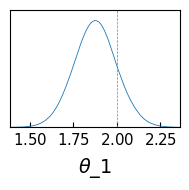

In [16]:
samples = zbi.sample_model(
    run_dir="runs/tutorial_02",
    checkpoint="round_00002_500.pt",
    n_samples=10_000,
)

zbi.plot(
    all_samples=[samples],
    output="posterior.png",
    run_dir="runs/tutorial_02",
    theta_true=[2.0],
    param_names=[r'\theta_1'],
)
from IPython.display import display, Image
display(Image(filename="runs/tutorial_02/plots/posterior.png"))

### Visualización de la evolución de bounds

Cada color muestra los bounds después de cada ronda. Se ve cómo solo las dimensiones
modeladas en cada ronda se angostan.

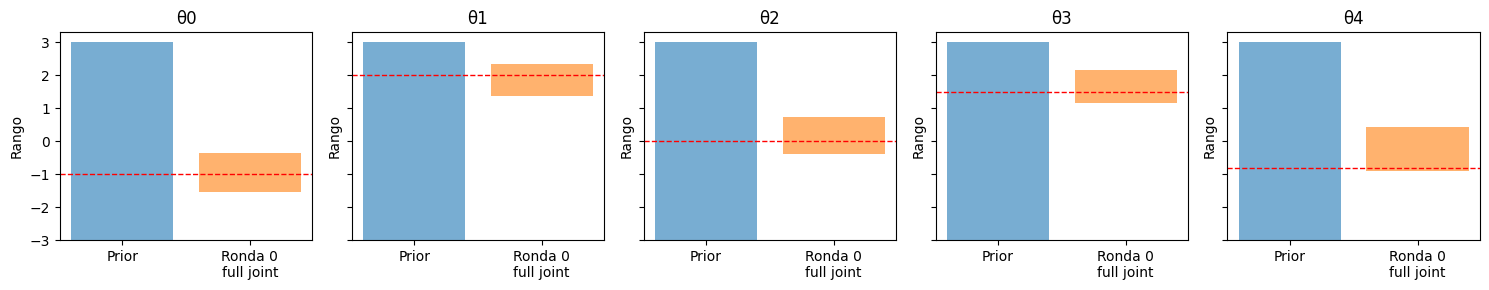

In [12]:
import json

def load_bounds(path):
    with open(path) as f:
        p = json.load(f)
    return [p["bounds"]["low"], p["bounds"]["high"]]

original = Uniform(torch.tensor([-3.0]*5), torch.tensor([3.0]*5))

# No tenemos proposal.json de antes de ronda 0, usamos prior original
bounds_r0 = load_bounds("runs/tutorial_02/proposal_original.json") if False else None

stages = [
    ("Prior", [[-3.0]*5, [3.0]*5]),
    ("Ronda 0\nfull joint", load_bounds("runs/tutorial_02/proposal.json")),
]

fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
for i in range(5):
    ax = axes[i]
    for label, (low, high) in stages:
        ax.bar(label, high[i]-low[i], bottom=low[i], alpha=0.6, label=label)
    ax.axhline(theta_true[i], color="red", ls="--", lw=1)
    ax.set_title(f"θ{i}")
    ax.set_ylabel("Rango")
plt.tight_layout()
plt.show()